In [4]:
import pickle
import numpy as np
from matplotlib import pyplot as plt 

In [5]:
def load_file(filename, data_path = '/home/filip/Documents/Research/Superconducting_vortices/Keldysh-non-eq/psBQP/'):
    with open(data_path + filename, 'rb') as input:
        data = pickle.load(input)
    return data

def save_data(data, filename, data_path = '/home/filip/Documents/Research/Superconducting_vortices/Results/'):
    with open(data_path + filename, 'wb') as output:  # Overwrites any existing file.
        pickle.dump(data, output)
        
def load_data(filename, data_path = '/home/filip/Documents/Research/Superconducting_vortices/Results/'):
    with open(data_path + filename, 'rb') as input:
        data = pickle.load(input)
    return data

def import_data_from_txt(file_name):
    # Read the title line
    with open(file_name, 'r') as f:
        title = f.readline().strip()

    # Read the data
    data = np.loadtxt(file_name, skiprows=1)
    print(np.shape(data))
    if np.shape(data)[1] == 2:
        # Split the data into two columns
        x = data[:, 0]
        y = data[:, 1]
    else:
        # Assume the data is already in two columns
        x = data[:, 1]
        y = data[:, -1]

    return title, data[:, 0], data[:, 1],data[:, 2], data[:, 3]



def save_two_column_text(data, filename):                                                         
      """                                                                                           
      Save 2-column data to a text file with whitespace separation.                                 
                                                                                                    
      Parameters                                                                                    
      ----------                                                                                    
      data : array-like, shape (N, 2)                                                               
          Two-column data to save. Can be a list of tuples, 2D numpy array, etc.                    
      filename : str                                                                                
          Path to the output text file.                                                             
                                                                                                    
      Examples                                                                                      
      --------                                                                                      
      >>> data = [[1.0, 2.5], [3.0, 4.2], [5.0, 6.8]]                                               
      >>> save_two_column_text(data, 'output.txt')                                                  
      """                                                                                           
      data = np.asarray(data)                                                                       
      if data.ndim != 2 or data.shape[1] != 2:                                                      
          raise ValueError(f"Data must be 2-column array, got shape {data.shape}")                  
                                                                                                    
      np.savetxt(filename, data, fmt='%.18e', delimiter=' ')                                        
                               

def read_two_column_text(filename):                                                               
      """                                                                                           
      Read 2-column data from a text file with whitespace separation.                               
                                                                                                    
      Parameters                                                                                    
      ----------                                                                                    
      filename : str                                                                                
          Path to the input text file.                                                              
                                                                                                    
      Returns                                                                                       
      -------                                                                                       
      data : numpy.ndarray, shape (N, 2)                                                            
          Two-column data array.                                                                    
                                                                                                    
      Examples                                                                                      
      --------                                                                                      
      >>> data = read_two_column_text('output.txt')                                                 
      >>> col1, col2 = data[:, 0], data[:, 1]                                                       
      """                                                                                           
      data = np.loadtxt(filename)                                                                   
      if data.ndim == 1:  # Single row case                                                         
          data = data.reshape(1, -1)                                                                
      if data.shape[1] != 2:                                                                        
          raise ValueError(f"File must contain exactly 2 columns, got {data.shape[1]}")             
                                                                                                    
      return data  


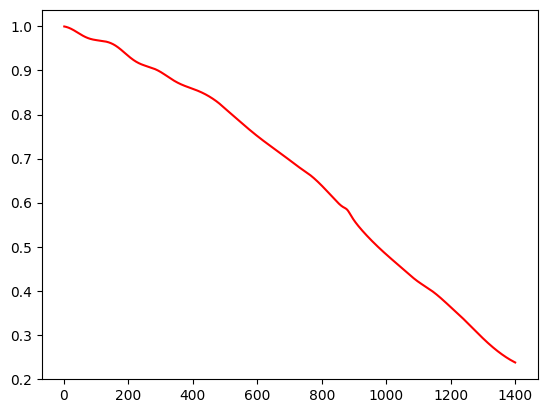

In [6]:
from scipy import signal

def lowpass_filter(t, f_t, cutoff_freq, filter_order=5, method='butter', filter_mask_function = None):
    """
    Apply a low-pass filter to a time-domain signal, removing frequencies above cutoff.

    Parameters:
    -----------
    t : array_like
        Time array (must be evenly spaced)
    f_t : array_like
        Function values at time points t
    cutoff_freq : float
        Cutoff frequency in Hz (frequencies above this will be filtered out)
    filter_order : int, optional
        Order of the Butterworth filter (default: 5)
    method : str, optional
        Filter method: 'butter' for Butterworth (default), 'fft' for FFT-based

    Returns:
    --------
    f_filtered : ndarray
        Filtered signal
    """

    if method == 'butter':
        # Calculate sampling frequency
        dt = t[1] - t[0]
        fs = 1.0 / dt

        # Normalize cutoff frequency (Nyquist frequency = fs/2)
        nyquist = fs / 2.0
        normalized_cutoff = cutoff_freq / nyquist

        if normalized_cutoff >= 1.0:
            raise ValueError(f"Cutoff frequency {cutoff_freq} Hz exceeds Nyquist frequency {nyquist} Hz")

        # Design Butterworth low-pass filter
        b, a = signal.butter(filter_order, normalized_cutoff, btype='low', analog=False)

        # Apply filter
        f_filtered = signal.filtfilt(b, a, f_t)

    elif method == 'fft':
        # FFT-based filtering
        N = len(f_t)
        dt = t[1] - t[0]

        # Compute FFT
        f_fft = np.fft.fft(f_t)
        freqs = np.fft.fftfreq(N, dt)

        # Create low-pass filter mask
        if filter_mask_function is None:
            filter_mask = np.abs(freqs) <= cutoff_freq
        else:
            filter_mask = filter_mask_function(freqs)
        # Apply filter in frequency domain
        f_fft_filtered = f_fft * filter_mask

        # Inverse FFT to get filtered signal
        f_filtered = np.fft.ifft(f_fft_filtered).real

    else:
        raise ValueError(f"Unknown method '{method}'. Use 'butter' or 'fft'")

    return f_filtered


def read_waveguide_csv(filename):                                                                 
    """                                                                                           
    Read waveguide bandwidth CSV file and extract frequency and transmission data.                
                                                                                                
    Parameters                                                                                    
    ----------                                                                                    
    filename : str                                                                                
        Path to the CSV file with columns: Freq_GHz, Transmittance                                
                                                                                                
    Returns                                                                                       
    -------                                                                                       
    frequency : numpy.ndarray                                                                     
        Frequency values in GHz                                                                   
    transmission : numpy.ndarray                                                                  
        Transmittance values                                                                      
                                                                                                
    Examples                                                                                      
    --------                                                                                      
    >>> freq, trans = read_waveguide_csv('waveguide bandwidth.csv')                               
    >>> print(f"Frequency range: {freq[0]:.2f} - {freq[-1]:.2f} GHz")                             
    >>> print(f"Transmission range: {trans.min():.6f} - {trans.max():.6f}")                       
    """                                                                                           
    # Load data, skipping the header row                                                          
    data = np.loadtxt(filename, delimiter=',', skiprows=1)                                        
                                                                                                
    # Extract columns                                                                             
    frequency = data[:, 0]                                                                        
    transmission = data[:, 1]                                                                     
                                                                                                
    return frequency, transmission                                                                

def linear_interp_simple(x_data, y_data, x_new):                                                  
    """                                                                                           
    Simple linear interpolation using numpy.                                                      
                                                                                                
    Parameters                                                                                    
    ----------                                                                                    
    x_data : array-like                                                                           
        x-coordinates of data points                                                              
    y_data : array-like                                                                           
        y-coordinates of data points                                                              
    x_new : array-like or float                                                                   
        Points at which to interpolate                                                            
                                                                                                
    Returns                                                                                       
    -------                                                                                       
    y_new : array or float                                                                        
        Interpolated values                                                                       
    """                                                                                           
    return np.interp(x_new, x_data, y_data)                                                                                           

csv_file = '/home/filip/Documents/Research/Superconducting_vortices/Keldysh-non-eq/psBQP/waveguide_bandwidth.csv'                                                                                    
freq, trans = read_waveguide_csv(csv_file)
plt.plot(freq, trans, 'red', label = 'Waveguide bandwidth')
frequency_rescale_factor = 1/1000 /2.029265256 # makes frequency in units of T_c
INTERPOLATOR_FILTER = lambda x: linear_interp_simple(freq * frequency_rescale_factor, trans, x)



## Dirty superconductor $T = 0.45T_c$

In [33]:
import numpy as np
title, data_1,data_2,data_3,data_4 = import_data_from_txt('/home/filip/Documents/Research/Superconducting_vortices/experimental_data/NbN data_7K_20K.txt')

normal_data_y = data_1
sc_data_y = data_2
normal_data_x = data_4
sc_data_x = data_3

eta_list = [0.1]
temp_list = [0.45]
phonon_scattering_list = [0.00]
labels = []
data_theory_dictionaries = []
for eta in eta_list:
    for temp in temp_list:
        for phonon_scattering in phonon_scattering_list:
            filename = 'Quasi-static-evolution-T:' + str(np.round(temp,2)) + ' phonons:' + str(np.round(phonon_scattering,2)) + ' eta:' + str(np.round(eta,2)) + '-Contact' + '-2.pkl'
            filename = 'dense_q_scan.dat'
            data_theory_dictionaries += [load_file(filename)]
            labels += [r'$\eta$=' + str(np.round(eta,2)) + r', $T$=' + str(np.round(temp,2)) + r', $\sigma_{\rm phon}$=' + str(np.round(phonon_scattering,2))]

print(data_theory_dictionaries[0].keys())

(99, 4)
dict_keys(['t_scan_T_c_scaling', 't_scan_gaps', 'q_scan_gaps', 'q_scan_currents', 'q_scan_Qs', 'q_scan_current_max', 'times', 'pulse_in', 'current_vs_time', 'gap_vs_time', 'q_vs_time', 'transmitivity', 'current_inside'])


/tmp/ipykernel_15218/329736899.py:8: RuntimeWarning: invalid value encountered in divide
  axs.scatter(np.abs(normal_data_x)/I_c/normal_data_y, normal_data_y, color = 'thistle', marker = 'o',label =  r'$T = 20K$', edgecolors='firebrick', s = 50, linewidth = 2)


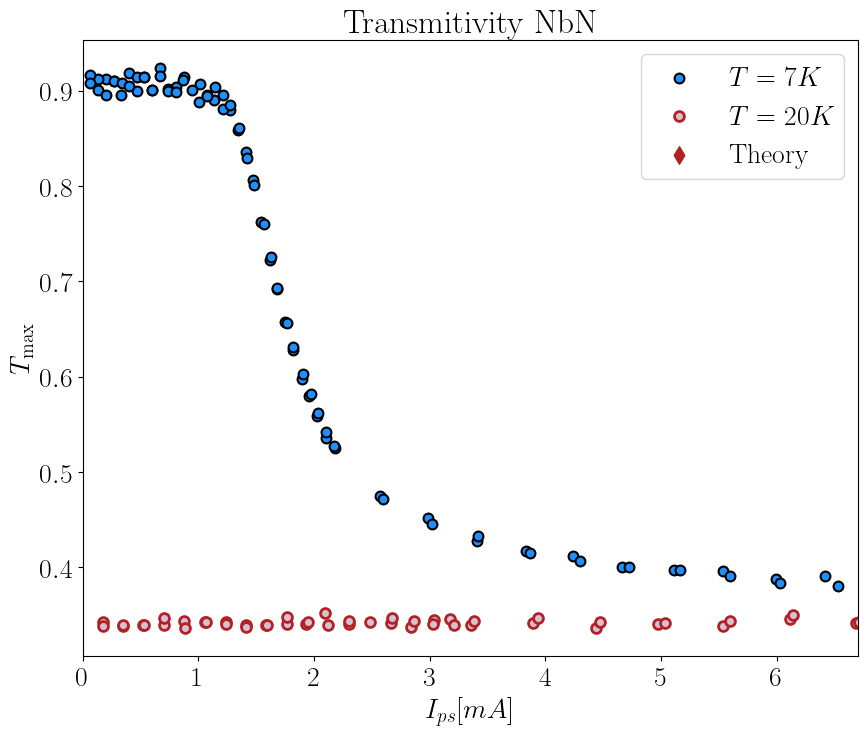

In [34]:

I_c = 37.3
fig, axs = plt.subplots(1,1,figsize = (10,8))
axs.set_ylabel(r'$T_{\rm max}$')
axs.set_xlabel(r'$I_{ps}[mA]$')
axs.set_title(r'Transmitivity NbN')

axs.scatter(np.abs(sc_data_x)/I_c/sc_data_y, sc_data_y, color = 'dodgerblue', marker = 'o',label = r'$T = 7K$', edgecolors='black', s = 50, linewidth = 1.5)
axs.scatter(np.abs(normal_data_x)/I_c/normal_data_y, normal_data_y, color = 'thistle', marker = 'o',label =  r'$T = 20K$', edgecolors='firebrick', s = 50, linewidth = 2)

index = 0
crt_dict = data_theory_dictionaries[index ]
#crt_dict = my_data
axs.scatter(np.max(np.array(crt_dict['pulse_in']), axis = 1)[:-5],crt_dict['transmitivity'][:-5], marker = 'd', color = 'firebrick', s = 80, label = r'Theory')
axs.plot(np.max(np.array(crt_dict['pulse_in'])[:-5], axis = 1),crt_dict['transmitivity'][:-5], color = 'firebrick', linewidth = 2.5)


#plt.ylim(0.2, 1)
plt.xlim(0,250/I_c)


plt.legend()
#plt.savefig('Dirty supercondutor-large eta-T vs I_in')

[] []


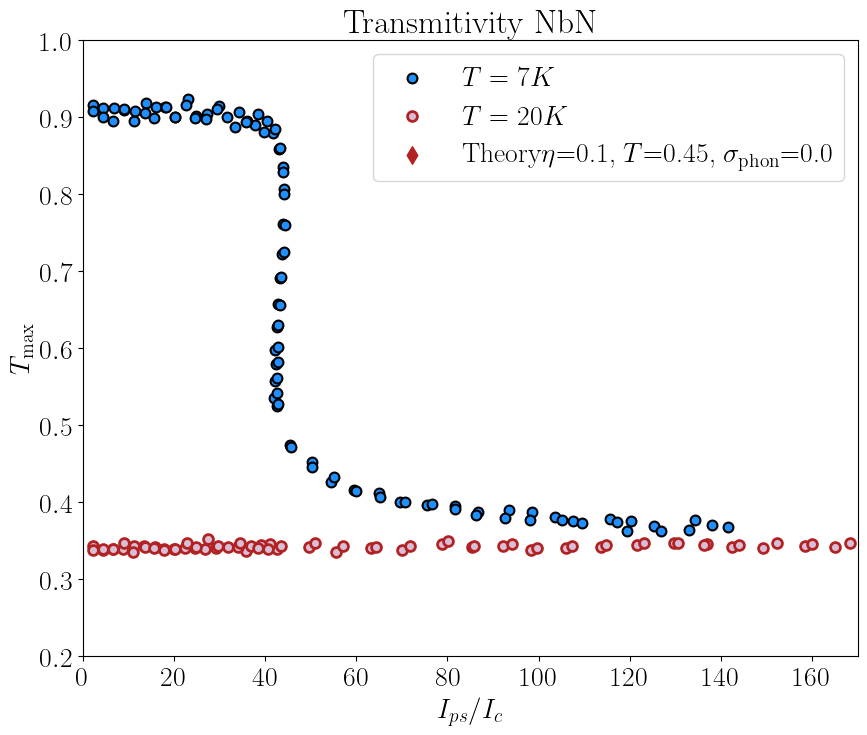

In [35]:

I_c = 37.3
fig, axs = plt.subplots(1,1,figsize = (10,8))
axs.set_ylabel(r'$T_{\rm max}$')
axs.set_xlabel(r'$I_{ps}/I_c$')
axs.set_title(r'Transmitivity NbN')

axs.scatter(np.abs(sc_data_x), sc_data_y, color = 'dodgerblue', marker = 'o',label = r'$T = 7K$', edgecolors='black', s = 50, linewidth = 1.5)
axs.scatter(np.abs(normal_data_x), normal_data_y, color = 'thistle', marker = 'o',label =  r'$T = 20K$', edgecolors='firebrick', s = 50, linewidth = 2)

plt.ylim(0.2, 1)
plt.xlim(0,170)


index = 0
crt_dict = data_theory_dictionaries[index ]
axs.scatter(np.max(np.array(crt_dict['pulse_in'])[:-1], axis = 1) * np.array(crt_dict['transmitivity'])[:-1]  *I_c,crt_dict['transmitivity'][:-1],  marker = 'd', color = 'firebrick', s = 80, label = r'Theory' + labels[index])
#axs.plot(np.max(np.array(crt_dict['pulse_in'])[:-5], axis = 1) * np.array(crt_dict['transmitivity'])[:-5],crt_dict['transmitivity'][:-5], color = 'firebrick', linewidth = 2.5)

x_data = np.max(np.array(crt_dict['pulse_in'])[:-1], axis = 1) * np.array(crt_dict['transmitivity'])[:-1]
y_data = crt_dict['transmitivity'][:-1]
x_data = np.append(x_data[:5],x_data[6:])
y_data = np.append(y_data[:5], y_data[6:])
x_data = np.append(x_data[:7],x_data[8:])[:-3]
y_data = np.append(y_data[:7], y_data[8:])[:-3]
plt.plot(x_data  *I_c,y_data, color = 'firebrick', linewidth = 2.5)

print(np.max(np.array(crt_dict['pulse_in'])[:-5], axis = 1) * np.array(crt_dict['transmitivity'])[:-5],crt_dict['transmitivity'][:-5])
plt.ylim(0.2, 1)

save_two_column_text(data = np.array([x_data,y_data]).T,filename='NbN_7K.dat')
plt.legend()
#plt.savefig('Dirty supercondutor-large eta-T vs I_in')


In [36]:
print(crt_dict.keys())

Q_list = np.linspace(0.0,0.55,100)
print(crt_dict['q_scan_gaps'])
print(crt_dict['q_scan_currents'])
scan_7k_Q = Q_list
scan_7k_gaps = crt_dict['q_scan_gaps']
scan_7k_currents = crt_dict['q_scan_currents'] 


dict_keys(['t_scan_T_c_scaling', 't_scan_gaps', 'q_scan_gaps', 'q_scan_currents', 'q_scan_Qs', 'q_scan_current_max', 'times', 'pulse_in', 'current_vs_time', 'gap_vs_time', 'q_vs_time', 'transmitivity', 'current_inside'])
[[1.5094709e+00 1.5094448e+00 1.5093658e+00 1.5092340e+00 1.5090488e+00
  1.5088114e+00 1.5085201e+00 1.5081769e+00 1.5077798e+00 1.5073298e+00
  1.5068270e+00 1.5062699e+00 1.5056598e+00 1.5049950e+00 1.5042773e+00
  1.5035050e+00 1.5026776e+00 1.5017965e+00 1.5008599e+00 1.4998676e+00
  1.4988202e+00 1.4977173e+00 1.4965571e+00 1.4953402e+00 1.4940677e+00
  1.4927373e+00 1.4913483e+00 1.4899015e+00 1.4883958e+00 1.4868315e+00
  1.4852076e+00 1.4835222e+00 1.4817774e+00 1.4799709e+00 1.4781020e+00
  1.4761703e+00 1.4741746e+00 1.4721149e+00 1.4699924e+00 1.4678018e+00
  1.4655458e+00 1.4632162e+00 1.4608240e+00 1.4583632e+00 1.4558305e+00
  1.4532276e+00 1.4505531e+00 1.4478022e+00 1.4449782e+00 1.4420779e+00
  1.4391003e+00 1.4360443e+00 1.4329095e+00 1.4296896e+00 1

In [37]:
data_index = 0

times = data_theory_dictionaries[data_index]['times'][-1]
data_x = data_theory_dictionaries[data_index]['pulse_in']
data_y = data_theory_dictionaries[data_index]['current_vs_time']
index = 12

filter_scale = 1.0

data_x = data_x[index]
data_y = data_y[index]

plt.plot(times, data_x, label = r'$I_{IN}(t)$')
plt.plot(times, data_y, label = r'$I(t)$')

filtered_data_x = lowpass_filter(times, data_x,  0.7 / 0.31 * filter_scale, method= 'fft', filter_mask_function= INTERPOLATOR_FILTER)
filtered_data_y = lowpass_filter(times, data_y,  0.7 / 0.31 * filter_scale, method= 'fft', filter_mask_function= INTERPOLATOR_FILTER)

plt.plot(times, filtered_data_x, label = r'$I_{IN}(t) filt$')
plt.plot(times, filtered_data_y, label = r'$I(t) filt$')

plt.legend()

filtered_pulse_in = []
filtered_transmitivity = []

for index in range(len(data_theory_dictionaries[data_index]['pulse_in'])):
    times = data_theory_dictionaries[data_index]['times'][-1]
    data_x = data_theory_dictionaries[data_index]['pulse_in']
    data_y = data_theory_dictionaries[data_index]['current_vs_time']
    data_x = data_x[index]
    data_y = data_y[index]

    filtered_data_x = lowpass_filter(times, data_x,  0.7 / 0.31 * filter_scale,method= 'fft', filter_mask_function= INTERPOLATOR_FILTER)
    filtered_data_y = lowpass_filter(times, data_y, 0.7 / 0.31 * filter_scale,method= 'fft', filter_mask_function= INTERPOLATOR_FILTER)

    filtered_pulse_in += [np.max(filtered_data_x)]
    filtered_transmitivity += [np.max(filtered_data_y) / np.max(filtered_data_x)]


print(filtered_pulse_in)
print(filtered_transmitivity)

IndexError: list index out of range

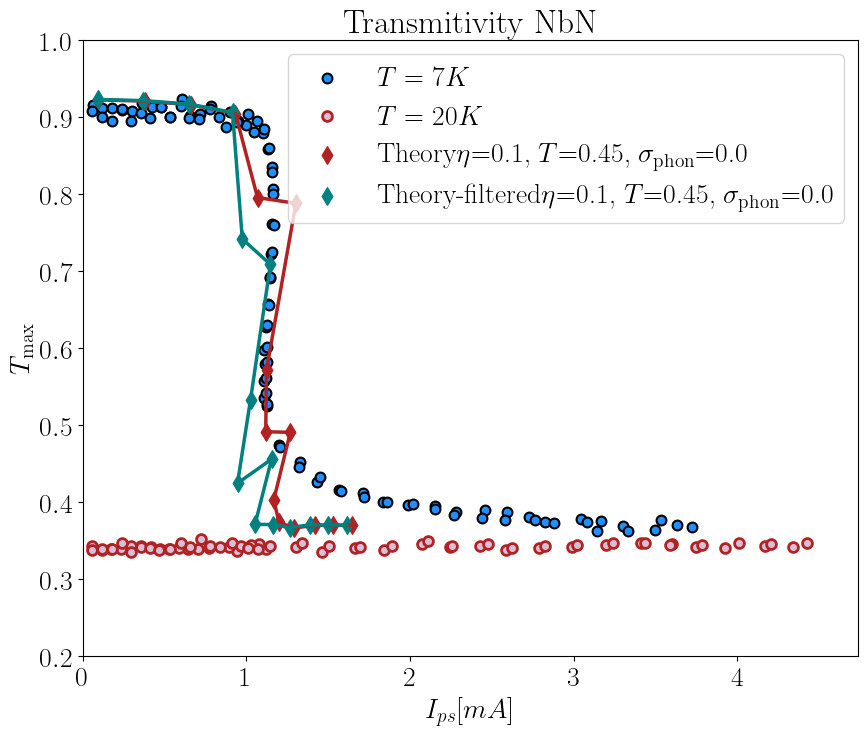

In [ ]:

I_c = 38
fig, axs = plt.subplots(1,1,figsize = (10,8))
axs.set_ylabel(r'$T_{\rm max}$')
axs.set_xlabel(r'$I_{ps}[mA]$')
axs.set_title(r'Transmitivity NbN')

axs.scatter(np.abs(sc_data_x)/I_c, sc_data_y, color = 'dodgerblue', marker = 'o',label = r'$T = 7K$', edgecolors='black', s = 50, linewidth = 1.5)
axs.scatter(np.abs(normal_data_x)/I_c, normal_data_y, color = 'thistle', marker = 'o',label =  r'$T = 20K$', edgecolors='firebrick', s = 50, linewidth = 2)

index = data_index
crt_dict = data_theory_dictionaries[index ]
axs.scatter(np.max(np.array(crt_dict['pulse_in'])[:-5], axis = 1) * np.array(crt_dict['transmitivity'])[:-5],crt_dict['transmitivity'][:-5], marker = 'd', color = 'firebrick', s = 80, label = r'Theory' + labels[index])
axs.plot(np.max(np.array(crt_dict['pulse_in'])[:-5], axis = 1) * np.array(crt_dict['transmitivity'])[:-5],crt_dict['transmitivity'][:-5], color = 'firebrick', linewidth = 2.5)

axs.scatter(np.array(filtered_pulse_in)[:-5] * np.array(filtered_transmitivity)[:-5], filtered_transmitivity[:-5], marker = 'd', color = 'teal', s = 80, label = r'Theory-filtered' + labels[index])
axs.plot(np.array(filtered_pulse_in)[:-5] * np.array(filtered_transmitivity)[:-5], filtered_transmitivity[:-5], color = 'teal', linewidth = 2.5)

plt.ylim(0.2, 1)
plt.xlim(0,180/I_c)

plt.legend()
#plt.savefig('Dirty supercondutor-large eta-T vs I_in')

In [ ]:
def compute_coherence_length(critical_current, r_n, max_current, gap_0):
    kbtc_over_e =  1.33 #(mV)
    # crtic_current in mA
    # return is in nm 
    return kbtc_over_e / r_n * max_current / critical_current * 30e3 /np.sqrt((gap_0 * 2))# #? Do we need T_C rescaling factor here as well? 

current_max = data_theory_dictionaries[data_index]['q_scan_current_max']
resistivity = 165
critical_current = 37.3
gap_0 = np.max(data_theory_dictionaries[data_index]['q_scan_gaps'])
print('Gap is ', np.round(gap_0,2))
coherence_length = compute_coherence_length(critical_current, resistivity, current_max, gap_0)
print('Coherence length is ', np.round(coherence_length,2), 'nm')

xi_t = np.sqrt(1.62/gap_0) * 5.24
print('xi_t is experimentally', np.round(xi_t,2), 'nm')


Gap is  1.5699999
Coherence length is  5.33 nm
xi_t is experimentally 5.33 nm


## Dirty superconductor $ T = 0.75T_c$

In [ ]:
import numpy as np
title, data_1,data_2,data_3,data_4 = import_data_from_txt('/home/filip/Documents/Research/Superconducting_vortices/experimental_data/Data12K.txt')

normal_data_y = data_4
sc_data_y = data_3
normal_data_x = data_4
sc_data_x = data_2


eta_list = [0.1]
temp_list = [0.75]
phonon_scattering_list = [0.00]
labels = []
data_theory_dictionaries = []
for eta in eta_list:
    for temp in temp_list:
        for phonon_scattering in phonon_scattering_list:
            filename = 'Quasi-static-evolution-T:' + str(np.round(temp,2)) + ' phonons:' + str(np.round(phonon_scattering,2)) + ' eta:' + str(np.round(eta,2)) + '-Contact-2.pkl'
            filename = 'dense_q_scan_highT.dat'
            data_theory_dictionaries += [load_file(filename)]
            labels += [r'$\eta$=' + str(np.round(eta,2)) + r', $T$=' + str(np.round(temp,2)) + r', $\sigma_{\rm phon}$=' + str(np.round(phonon_scattering,2))]

print(data_theory_dictionaries[0].keys())

(100, 4)
dict_keys(['t_scan_T_c_scaling', 't_scan_gaps', 'q_scan_gaps', 'q_scan_currents', 'q_scan_Qs', 'q_scan_current_max', 'times', 'pulse_in', 'current_vs_time', 'gap_vs_time', 'q_vs_time', 'transmitivity', 'current_inside'])


/tmp/ipykernel_15218/3533475903.py:8: RuntimeWarning: invalid value encountered in divide
  axs.scatter(np.abs(normal_data_x)/I_c/normal_data_y, normal_data_y, color = 'thistle', marker = 'o',label =  r'$T = 20K$', edgecolors='firebrick', s = 50, linewidth = 2)


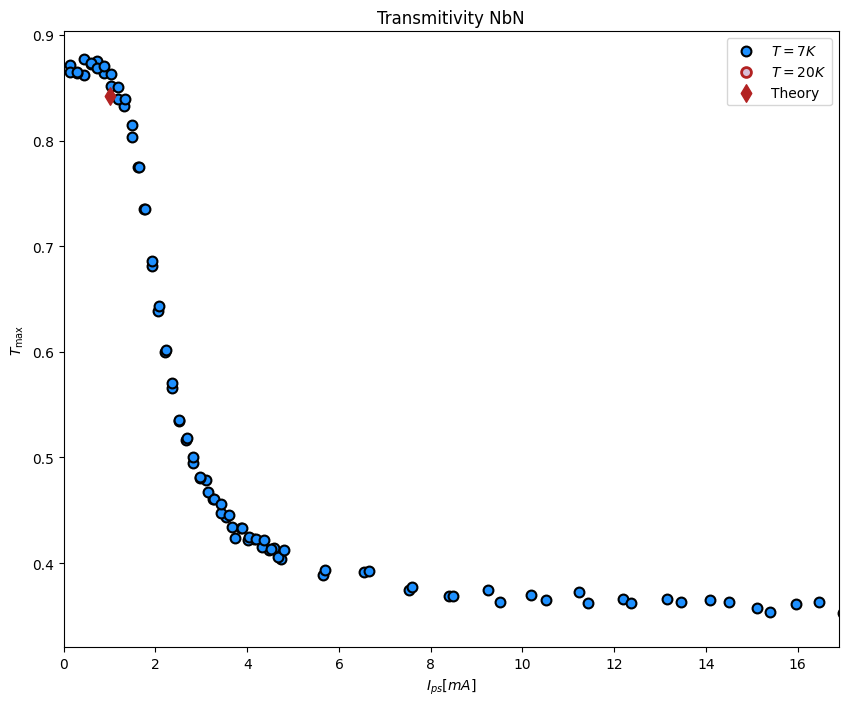

In [ ]:

I_c = 14.8
fig, axs = plt.subplots(1,1,figsize = (10,8))
axs.set_ylabel(r'$T_{\rm max}$')
axs.set_xlabel(r'$I_{ps}[mA]$')
axs.set_title(r'Transmitivity NbN')

axs.scatter(np.abs(sc_data_x)/I_c/sc_data_y, sc_data_y, color = 'dodgerblue', marker = 'o',label = r'$T = 7K$', edgecolors='black', s = 50, linewidth = 1.5)
axs.scatter(np.abs(normal_data_x)/I_c/normal_data_y, normal_data_y, color = 'thistle', marker = 'o',label =  r'$T = 20K$', edgecolors='firebrick', s = 50, linewidth = 2)

index = 0
crt_dict = data_theory_dictionaries[index ]
#crt_dict = my_data
axs.scatter(np.max(np.array(crt_dict['pulse_in']), axis = 1),crt_dict['transmitivity'], marker = 'd', color = 'firebrick', s = 80, label = r'Theory')
axs.plot(np.max(np.array(crt_dict['pulse_in']), axis = 1),crt_dict['transmitivity'], color = 'firebrick', linewidth = 2.5)


#plt.ylim(0.2, 1)
plt.xlim(0,250/I_c)

plt.legend()
#plt.savefig('Dirty supercondutor-large eta-T vs I_in')

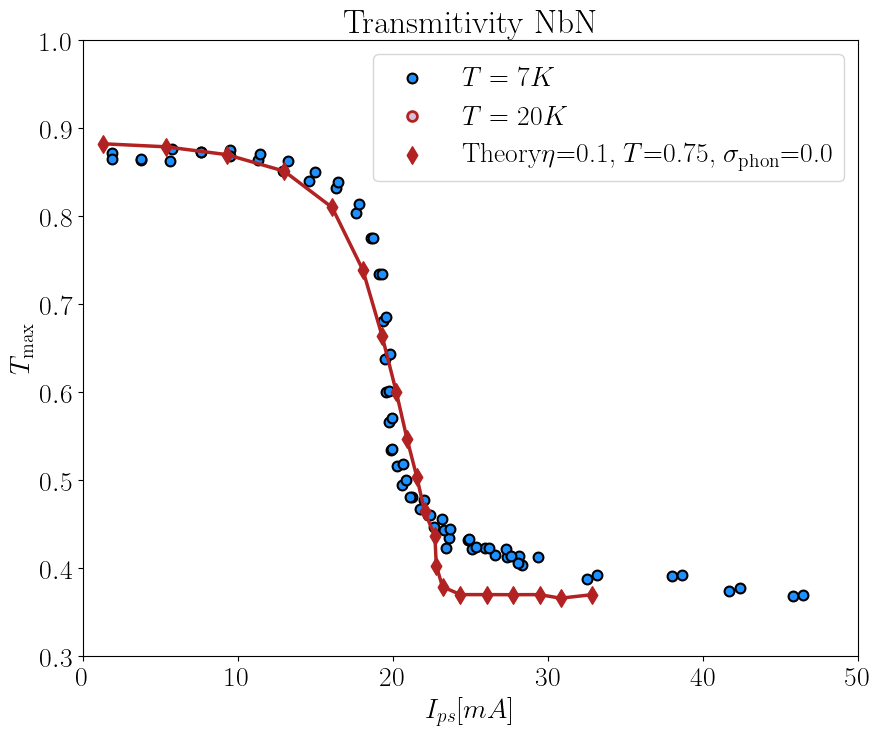

In [ ]:


I_c = 14.8
fig, axs = plt.subplots(1,1,figsize = (10,8))
axs.set_ylabel(r'$T_{\rm max}$')
axs.set_xlabel(r'$I_{ps}[mA]$')
axs.set_title(r'Transmitivity NbN')

axs.scatter(np.abs(sc_data_x), sc_data_y, color = 'dodgerblue', marker = 'o',label = r'$T = 7K$', edgecolors='black', s = 50, linewidth = 1.5)
axs.scatter(np.abs(normal_data_x), normal_data_y, color = 'thistle', marker = 'o',label =  r'$T = 20K$', edgecolors='firebrick', s = 50, linewidth = 2)

plt.ylim(0.2, 1)
plt.xlim(0,170)


index = 0
crt_dict = data_theory_dictionaries[index ]
axs.scatter(np.max(np.array(crt_dict['pulse_in']), axis = 1) * np.array(crt_dict['transmitivity']) * I_c,crt_dict['transmitivity'], marker = 'd', color = 'firebrick', s = 80, label = r'Theory' + labels[index])
axs.plot(np.max(np.array(crt_dict['pulse_in']), axis = 1) * np.array(crt_dict['transmitivity']) * I_c ,crt_dict['transmitivity'], color = 'firebrick', linewidth = 2.5)

x_data = np.max(np.array(crt_dict['pulse_in']), axis = 1) * np.array(crt_dict['transmitivity'])
y_data = crt_dict['transmitivity']

save_two_column_text(data = np.array([x_data,y_data]).T,filename='NbN_12K.dat')

plt.ylim(0.3, 1)
plt.xlim(0,50)

plt.legend()
#plt.savefig('Dirty supercondutor-large eta-T vs I_in')


In [38]:
data_index = 0

times = data_theory_dictionaries[data_index]['times'][-1]
data_x = data_theory_dictionaries[data_index]['pulse_in']
data_y = data_theory_dictionaries[data_index]['current_vs_time']
index = 12

filter_scale = 1.0

data_x = data_x[index]
data_y = data_y[index]

plt.plot(times, data_x, label = r'$I_{IN}(t)$')
plt.plot(times, data_y, label = r'$I(t)$')

filtered_data_x = lowpass_filter(times, data_x,  0.7 / 0.31 * filter_scale, method= 'fft', filter_mask_function= INTERPOLATOR_FILTER)
filtered_data_y = lowpass_filter(times, data_y,  0.7 / 0.31 * filter_scale, method= 'fft', filter_mask_function= INTERPOLATOR_FILTER)

plt.plot(times, filtered_data_x, label = r'$I_{IN}(t) filt$')
plt.plot(times, filtered_data_y, label = r'$I(t) filt$')

plt.legend()

filtered_pulse_in = []
filtered_transmitivity = []

for index in range(len(data_theory_dictionaries[data_index]['pulse_in'])):
    times = data_theory_dictionaries[data_index]['times'][-1]
    data_x = data_theory_dictionaries[data_index]['pulse_in']
    data_y = data_theory_dictionaries[data_index]['current_vs_time']
    data_x = data_x[index]
    data_y = data_y[index]

    filtered_data_x = lowpass_filter(times, data_x,  0.7 / 0.31 * filter_scale,method= 'fft', filter_mask_function= INTERPOLATOR_FILTER)
    filtered_data_y = lowpass_filter(times, data_y, 0.7 / 0.31 * filter_scale,method= 'fft', filter_mask_function= INTERPOLATOR_FILTER)

    filtered_pulse_in += [np.max(filtered_data_x)]
    filtered_transmitivity += [np.max(filtered_data_y) / np.max(filtered_data_x)]


print(filtered_pulse_in)
print(filtered_transmitivity)

IndexError: list index out of range

NameError: name 'filtered_pulse_in' is not defined

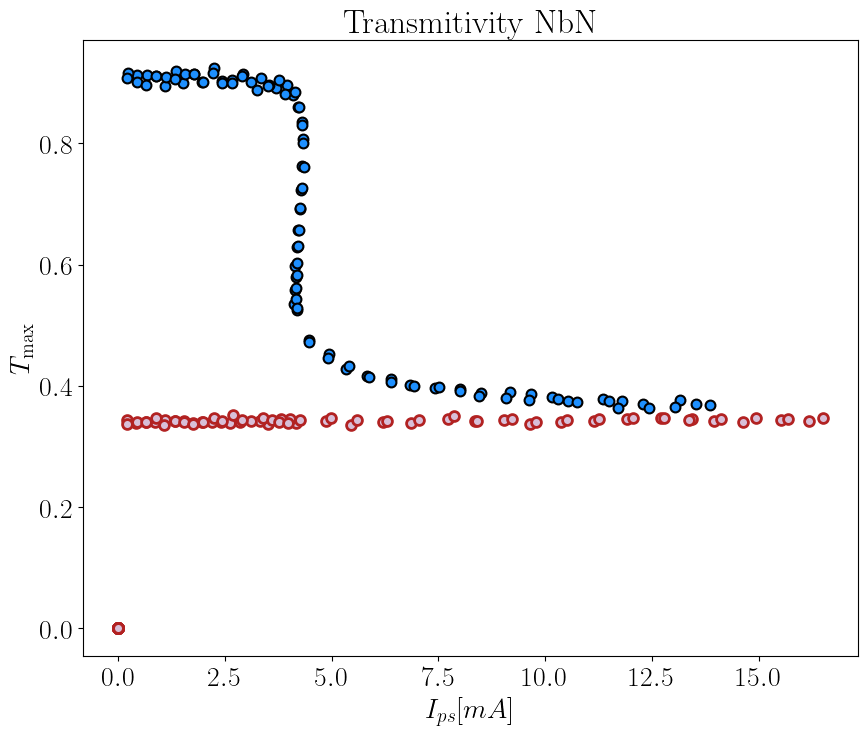

In [39]:

I_c = 10.2
fig, axs = plt.subplots(1,1,figsize = (10,8))
axs.set_ylabel(r'$T_{\rm max}$')
axs.set_xlabel(r'$I_{ps}[mA]$')
axs.set_title(r'Transmitivity NbN')

axs.scatter(np.abs(sc_data_x)/I_c, sc_data_y, color = 'dodgerblue', marker = 'o',label = r'$T = 7K$', edgecolors='black', s = 50, linewidth = 1.5)
axs.scatter(np.abs(normal_data_x)/I_c, normal_data_y, color = 'thistle', marker = 'o',label =  r'$T = 20K$', edgecolors='firebrick', s = 50, linewidth = 2)

index = data_index
crt_dict = data_theory_dictionaries[index ]
axs.scatter(np.max(np.array(crt_dict['pulse_in']), axis = 1) * np.array(crt_dict['transmitivity']),crt_dict['transmitivity'], marker = 'd', color = 'firebrick', s = 80, label = r'Theory' + labels[index])
axs.plot(np.max(np.array(crt_dict['pulse_in']), axis = 1) * np.array(crt_dict['transmitivity']),crt_dict['transmitivity'], color = 'firebrick', linewidth = 2.5)

axs.scatter(np.array(filtered_pulse_in) * np.array(filtered_transmitivity), filtered_transmitivity, marker = 'd', color = 'teal', s = 80, label = r'Theory-filtered' + labels[index])
axs.plot(np.array(filtered_pulse_in) * np.array(filtered_transmitivity), filtered_transmitivity, color = 'teal', linewidth = 2.5)

plt.ylim(0.2, 1)
plt.xlim(0,180/I_c)

plt.legend()
#plt.savefig('Dirty supercondutor-large eta-T vs I_in')

In [ ]:

Q_list = np.linspace(0.0,0.55,100)
print(crt_dict['q_scan_gaps'])
print(crt_dict['q_scan_currents'])
scan_12k_Q = Q_list
scan_12k_gaps = crt_dict['q_scan_gaps']
scan_12k_currents = crt_dict['q_scan_currents'] 

[[1.2096072e+00 1.2095506e+00 1.2093806e+00 1.2090983e+00 1.2086993e+00
  1.2081873e+00 1.2075614e+00 1.2068199e+00 1.2059631e+00 1.2049892e+00
  1.2039020e+00 1.2026970e+00 1.2013729e+00 1.1999313e+00 1.1983706e+00
  1.1966900e+00 1.1948878e+00 1.1929631e+00 1.1909145e+00 1.1887437e+00
  1.1864455e+00 1.1840203e+00 1.1814643e+00 1.1787769e+00 1.1759607e+00
  1.1730070e+00 1.1699208e+00 1.1666927e+00 1.1633271e+00 1.1598018e+00
  1.1561450e+00 1.1523402e+00 1.1483890e+00 1.1442804e+00 1.1400166e+00
  1.1355947e+00 1.1310070e+00 1.1262559e+00 1.1213325e+00 1.1162366e+00
  1.1109608e+00 1.1055030e+00 1.0998589e+00 1.0940202e+00 1.0879833e+00
  1.0817475e+00 1.0753000e+00 1.0686378e+00 1.0617549e+00 1.0546408e+00
  1.0472933e+00 1.0396993e+00 1.0318553e+00 1.0237496e+00 1.0153708e+00
  1.0067129e+00 9.9776542e-01 9.8850852e-01 9.7893149e-01 9.6903157e-01
  9.5879662e-01 9.4818819e-01 9.3718636e-01 9.2581290e-01 9.1405016e-01
  9.0179950e-01 8.8904417e-01 8.7590277e-01 8.6230314e-01 8.4794

In [ ]:
def compute_coherence_length(critical_current, r_n, max_current, gap_0):
    kbtc_over_e =  1.33 #(mV)
    # crtic_current in mA
    # return is in nm 
    return kbtc_over_e / r_n * max_current / critical_current * 30e3 /np.sqrt(gap_0 * 2)# 

current_max = data_theory_dictionaries[data_index]['q_scan_current_max']
resistivity = 165
critical_current = 14.8
gap_0 = np.max(data_theory_dictionaries[data_index]['q_scan_gaps'])
coherence_length = compute_coherence_length(critical_current, resistivity, current_max, gap_0)
print('Coherence length is ', np.round(coherence_length,1), 'nm')

xi_t = np.sqrt(1.62/gap_0) * 5.24
print('xi_t is experimentally', np.round(xi_t,1), 'nm')

Coherence length is  5.7000003 nm
xi_t is experimentally 6.1 nm


In [ ]:
print(data_theory_dictionaries[data_index]['q_scan_gaps'])

[[1.2096072e+00 1.2095506e+00 1.2093806e+00 1.2090983e+00 1.2086993e+00
  1.2081873e+00 1.2075614e+00 1.2068199e+00 1.2059631e+00 1.2049892e+00
  1.2039020e+00 1.2026970e+00 1.2013729e+00 1.1999313e+00 1.1983706e+00
  1.1966900e+00 1.1948878e+00 1.1929631e+00 1.1909145e+00 1.1887437e+00
  1.1864455e+00 1.1840203e+00 1.1814643e+00 1.1787769e+00 1.1759607e+00
  1.1730070e+00 1.1699208e+00 1.1666927e+00 1.1633271e+00 1.1598018e+00
  1.1561450e+00 1.1523402e+00 1.1483890e+00 1.1442804e+00 1.1400166e+00
  1.1355947e+00 1.1310070e+00 1.1262559e+00 1.1213325e+00 1.1162366e+00
  1.1109608e+00 1.1055030e+00 1.0998589e+00 1.0940202e+00 1.0879833e+00
  1.0817475e+00 1.0753000e+00 1.0686378e+00 1.0617549e+00 1.0546408e+00
  1.0472933e+00 1.0396993e+00 1.0318553e+00 1.0237496e+00 1.0153708e+00
  1.0067129e+00 9.9776542e-01 9.8850852e-01 9.7893149e-01 9.6903157e-01
  9.5879662e-01 9.4818819e-01 9.3718636e-01 9.2581290e-01 9.1405016e-01
  9.0179950e-01 8.8904417e-01 8.7590277e-01 8.6230314e-01 8.4794

## Static curves

In [40]:

plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams.update({'font.size': 20})
plt.rcParams['text.usetex'] = True


100


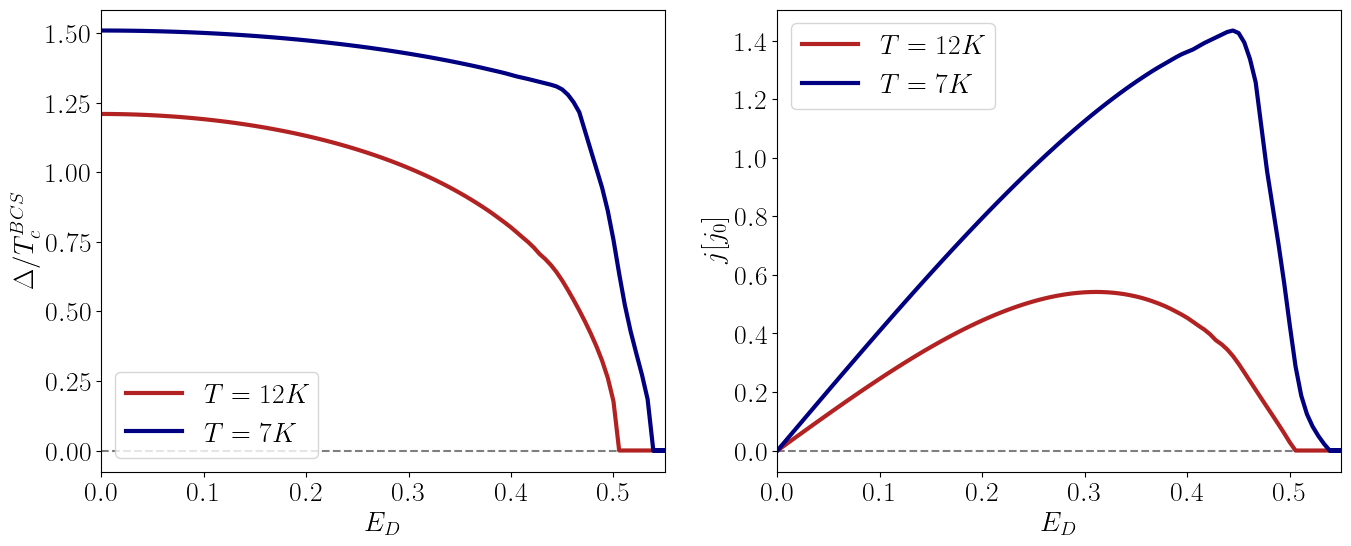

In [61]:
fig,axes = plt.subplots(1,2,figsize = (16,6))

ax = axes[0]
ax.set_ylabel(r'$\Delta/T_c^{BCS}$')
ax.set_xlabel(r'$E_D$')

#indicies_out = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 24, 26])
indicies_out = np.append(np.arange(100)[Q_list<  0.42],np.arange(100)[Q_list>  0.435])
indicies_out = np.delete(indicies_out, [82,84])
ax.hlines(0.0,scan_7k_Q[0],scan_7k_Q[-1], 'k', 'dashed',alpha = 0.5)
print(np.size(scan_7k_Q))
ax.plot(scan_12k_Q, scan_12k_gaps[0], color = 'firebrick', linewidth = 3, label = r'$T = 12K$')
ax.plot(np.append(scan_7k_Q[indicies_out],scan_7k_Q[-3:-1]), np.append(scan_7k_gaps[0][indicies_out],[0,0]), color = 'navy', linewidth = 3, label = r'$T = 7K$')
ax.legend()

ax.set_xlim(0,0.55)

ax = axes[1]
ax.hlines(0.0,scan_7k_Q[0],scan_7k_Q[-1], 'k', 'dashed',alpha = 0.5)
ax.plot(scan_12k_Q, scan_12k_currents[0], color = 'firebrick', linewidth = 3, label = r'$T = 12K$')
ax.plot(np.append(scan_7k_Q[indicies_out],scan_7k_Q[-3:-1]), np.append(scan_7k_currents[0][indicies_out],[0,0]), color = 'navy', linewidth = 3, label = r'$T = 7K$')
ax.set_xlim(0,0.55)
ax.set_xlabel(r'$E_D$')
ax.set_ylabel(r'$j[j_0]$')

ax.legend()

plt.savefig('current_gap_scan.png', bbox_inches = 'tight', dpi = 600)



## GL Theory for NbN

0.8982835632541475


/tmp/ipykernel_7424/2503461632.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


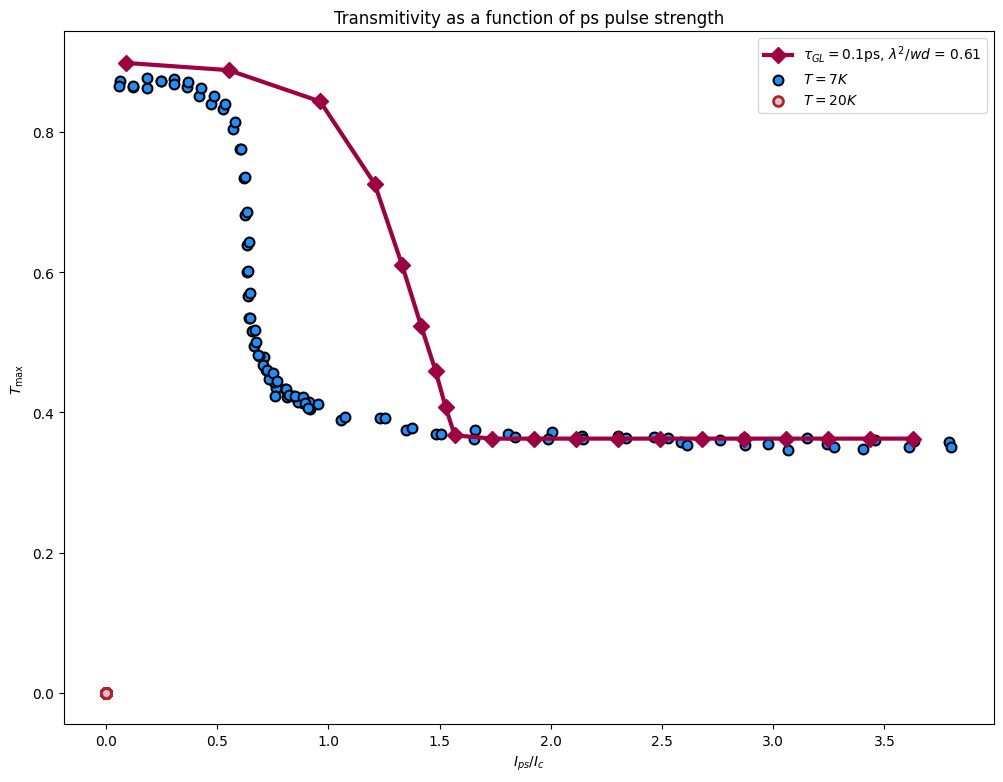

In [22]:
import matplotlib.cm as cm
import numpy as np


max_iters = [1]
scaling_factor =1 
def get_colors(N, cmap_name):
    cmap = cm.get_cmap(cmap_name)
    colors = [cmap(i) for i in np.linspace(0, 1, N)]
    return colors

# labmda = 350 nm
#filename_list = ['Transmission-for-tau_gl=7.0ps-w_vs_lambda=12.5-with_DC_bias=0.0','Transmission-for-tau_gl=5.0ps-w_vs_lambda=12.5-with_DC_bias=0.0','Transmission-for-tau_gl=3.0ps-w_vs_lambda=22.22-with_DC_bias=0.0']
#filename_list = ['Transmission-for-tau_gl=3.0ps-w_vs_lambda=1.02-with_DC_bias=0.0 and resistivity-5.31','Transmission-for-tau_gl=1.0ps-w_vs_lambda=1.02-with_DC_bias=0.0 and resistivity-5.31','Transmission-for-tau_gl=1.0ps-w_vs_lambda=0.69-with_DC_bias=0.0 and resistivity-5.31','Transmission-for-tau_gl=3.0ps-w_vs_lambda=0.69-with_DC_bias=0.0 and resistivity-5.31','Transmission-for-tau_gl=3.0ps-w_vs_lambda=0.69-with_DC_bias=0.0 and resistivity-13.27','Transmission-for-tau_gl=1.0ps-w_vs_lambda=0.69-with_DC_bias=0.0 and resistivity-13.27','Transmission-for-tau_gl=0.5ps-w_vs_lambda=0.69-with_DC_bias=0.0 and resistivity-13.27','Transmission-for-tau_gl=5.0ps-w_vs_lambda=0.69-with_DC_bias=0.0 and resistivity-13.27']
#filename_list += ['Transmission-for-tau_gl=3.0ps-w_vs_lambda=4.08-with_DC_bias=0.0 and resistivity-13.27','Transmission-for-tau_gl=3.0ps-w_vs_lambda=4.08-with_DC_bias=0.0 and resistivity-13.27']
fig, axs = plt.subplots(1,1,figsize = (12,9))
axs.set_ylabel(r'$T_{\rm max}  $')
axs.set_xlabel(r'$I_{ps}/I_c$')
axs.set_title(r'Transmitivity as a function of ps pulse strength')



#gl_times = [0.3] # 1.0
#ab_penetrations = [300]
#I_cs = [0.885]
#normal_resistances = [140]

#gl_times = [0.3,0.5]
#ab_penetrations = [300]
#I_cs = [0.885]
#normal_resistances = [150]
#sf_fractions = [2]

"""
gl_times = [2.0,1.0,0.5] # 
ab_penetrations = [300]
I_cs = [0.885]
normal_resistances = [140]
normal_fluid_collision_times = [0.8,0.01,0.3,3.0] 
sf_to_normal_fractions = [4.0,0.0]
max_iters = [1]
#normal_fluid_collision_times = [1.0,0.01]

"""

"""
gl_times = [0.3,0.5] # 0.1,0.2
ab_penetrations = [300]
I_cs = [0.885]
normal_resistances = [140]
normal_fluid_collision_times = [0.8,0.3]
sf_to_normal_fractions = [4.0,0.0]
"""

"""
gl_times = [1.0] # ,1.0,2.0,0.2
ab_penetrations = [200] # 300, 400, 200
I_cs = [2.01] # 0.885, 0.515, 2.01
normal_resistances = [140]
normal_fluid_collision_times = [0.3] # 0.3 
sf_to_normal_fractions = [0.0,4.0]
max_iter = 1
#gl_times = [1,2,3,10,15]
"""

gl_times = [0.1]
ab_penetrations = [350]
I_cs = [0.68]
normal_resistances = [170]

sf_to_normal_fractions = [0.0]
max_iter = 1

normal_fluid_collision_times = [0]
my_colors = ['teal','orange','purple','lightblue']
colors = get_colors(8, 'Spectral')
my_colors = colors

filename_list = []
for penetration_index in range(len(ab_penetrations)):
    for gl_time in gl_times:
        for normal_fluid_collision_time in normal_fluid_collision_times:
            for superfluid_fraction in sf_to_normal_fractions:
                for max_iter in max_iters:
                    ps = 1 
                    um = 1 
                    nm = 1e-3 * um
                    ohm = 1

                    t_pulse = 1 * ps #ps 

                    sample_length = 30 * um
                    light_velocity = 3e2 * um/ps
                    z_0 = 376.7 * ohm

                    width = 10 * um
                    ab_penetration = 350 * nm # 350 * nm
                    thickness = 20 * nm
                    transmission_impedance = 50 * ohm

                    auxiliary_series_impedance = 5 * ohm * 0
                    # currents are measured in units of \phi_0/2/\pi/\xi
                    # units of current I_0

                    coherence_length = 4 * nm
                    i_0 = 0.261 /coherence_length # turns current into units of mA
                    v_0 = 0.329 / coherence_length * sample_length / t_pulse # turns voltage into units of mV

                    ab_penetration = ab_penetrations[penetration_index] * nm
                    I_c = I_cs[penetration_index]
                    I_dc = 0 # run also for - this and for 14.3/18.2 biases with plus and minus
                    I_ps_list = np.linspace(0.1,15,30) * I_c 

                    N_sites = 100
                    times = np.linspace(-5,10,200)
                    resistance = normal_resistances[0]/z_0
                    parameters = {'t_p/tau_GL':t_pulse/gl_time,'tau_N/t_p': normal_fluid_collision_time/t_pulse,'resistivity':resistance * light_velocity * t_pulse/sample_length, 'W/lambda':width * thickness/ab_penetration**2, 'xi/W': coherence_length/width, 'v_0/i_0/z_T':v_0/i_0/transmission_impedance, 'v_0/i_0/z_0' : v_0/i_0/z_0, 'z_s/z_T': auxiliary_series_impedance/transmission_impedance,'sf_to_normal_fraction' : superfluid_fraction }

                    filename_list += ['NbN-Transmission-with-resistor-for-tau_gl={}ps-w_vs_lambda={}-with_DC_bias={} and resistivity-{}'.format(np.round(1/parameters['t_p/tau_GL'],2), np.round(parameters['W/lambda'],2),np.round(I_dc/I_c,2), np.round(parameters['resistivity'],2))]



for filename in filename_list:
    params, I_ps_list,i_max_list = load_data(filename)
    I_c = params['I_c']
    #axs.scatter((i_max_list/I_c ), (i_max_list/I_ps_list  ) * scaling_factor ,linewidth = 2, label = r'$\tau_{GL} = $' + str(np.round(1/params['t_p/tau_GL'],1)) + 'ps' + ', w/lambda = ' + str(np.round(params['W/lambda'],2)) + 'R = ' + str(np.round(params['sf_to_normal_fraction'],2)) + 'L_n = ' + str(np.round(params['tau_N/t_p'],2)), color = my_colors[filename_list.index(filename) % len(my_colors)],edgecolor = 'black', zorder = 10, s = 130)

    print(np.max(i_max_list/I_ps_list))
    x_data = i_max_list/I_c
    y_data = (i_max_list/I_ps_list  ) * scaling_factor
    axs.plot(x_data, y_data,linewidth = 3, label = r'$\tau_{GL} = $' + str(np.round(1/params['t_p/tau_GL'],1)) + 'ps' + r', $\lambda^2/wd$ = ' + str(np.round(1/params['W/lambda'],2)), color = my_colors[filename_list.index(filename) % len(my_colors)], zorder = 10, marker = 'D', markersize = 8)
    save_two_column_text(data = np.array([x_data,y_data]).T,filename='NbN_7K_GL' + '.dat')


I_c = 30.87
axs.scatter(np.abs(sc_data_x)/I_c , sc_data_y, color = 'dodgerblue', marker = 'o',label = r'$T = 7K$', edgecolors='black', s = 50, linewidth = 1.5)
axs.scatter(np.abs(normal_data_x)/I_c , normal_data_y, color = 'thistle', marker = 'o',label =  r'$T = 20K$', edgecolors='firebrick', s = 50, linewidth = 2)

plt.legend()


plt.show()



0.8719931802870279


/tmp/ipykernel_7424/1191542750.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


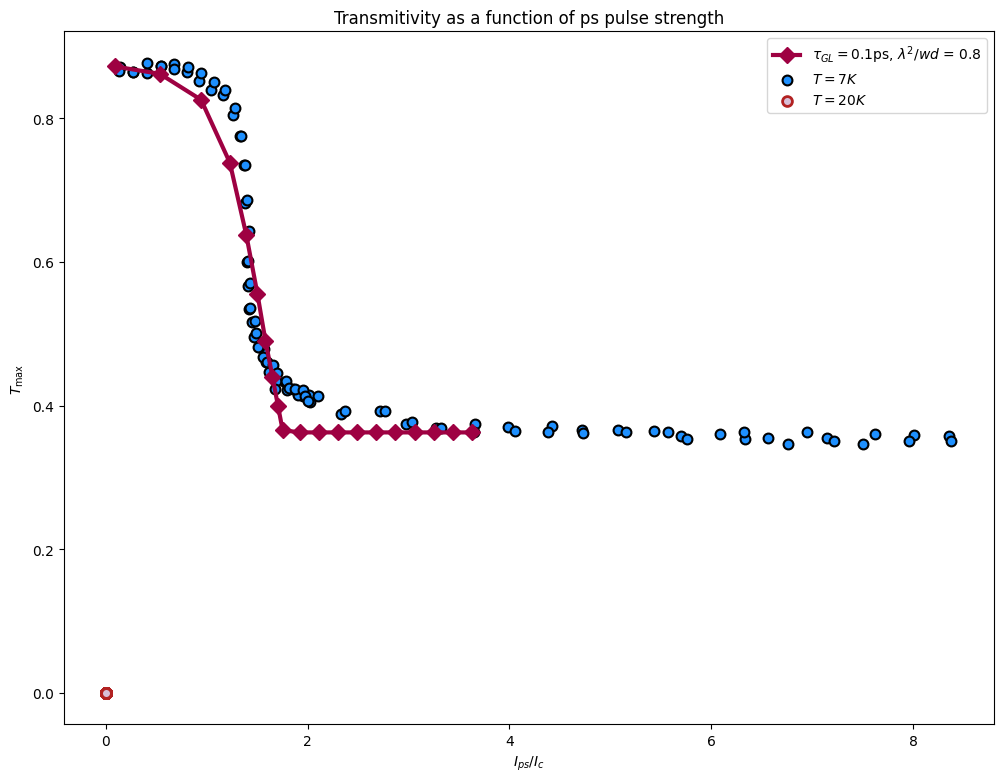

In [26]:
import matplotlib.cm as cm
import numpy as np


max_iters = [1]
scaling_factor =1 
def get_colors(N, cmap_name):
    cmap = cm.get_cmap(cmap_name)
    colors = [cmap(i) for i in np.linspace(0, 1, N)]
    return colors

# labmda = 350 nm
#filename_list = ['Transmission-for-tau_gl=7.0ps-w_vs_lambda=12.5-with_DC_bias=0.0','Transmission-for-tau_gl=5.0ps-w_vs_lambda=12.5-with_DC_bias=0.0','Transmission-for-tau_gl=3.0ps-w_vs_lambda=22.22-with_DC_bias=0.0']
#filename_list = ['Transmission-for-tau_gl=3.0ps-w_vs_lambda=1.02-with_DC_bias=0.0 and resistivity-5.31','Transmission-for-tau_gl=1.0ps-w_vs_lambda=1.02-with_DC_bias=0.0 and resistivity-5.31','Transmission-for-tau_gl=1.0ps-w_vs_lambda=0.69-with_DC_bias=0.0 and resistivity-5.31','Transmission-for-tau_gl=3.0ps-w_vs_lambda=0.69-with_DC_bias=0.0 and resistivity-5.31','Transmission-for-tau_gl=3.0ps-w_vs_lambda=0.69-with_DC_bias=0.0 and resistivity-13.27','Transmission-for-tau_gl=1.0ps-w_vs_lambda=0.69-with_DC_bias=0.0 and resistivity-13.27','Transmission-for-tau_gl=0.5ps-w_vs_lambda=0.69-with_DC_bias=0.0 and resistivity-13.27','Transmission-for-tau_gl=5.0ps-w_vs_lambda=0.69-with_DC_bias=0.0 and resistivity-13.27']
#filename_list += ['Transmission-for-tau_gl=3.0ps-w_vs_lambda=4.08-with_DC_bias=0.0 and resistivity-13.27','Transmission-for-tau_gl=3.0ps-w_vs_lambda=4.08-with_DC_bias=0.0 and resistivity-13.27']
fig, axs = plt.subplots(1,1,figsize = (12,9))
axs.set_ylabel(r'$T_{\rm max}  $')
axs.set_xlabel(r'$I_{ps}/I_c$')
axs.set_title(r'Transmitivity as a function of ps pulse strength')



#gl_times = [0.3] # 1.0
#ab_penetrations = [300]
#I_cs = [0.885]
#normal_resistances = [140]

#gl_times = [0.3,0.5]
#ab_penetrations = [300]
#I_cs = [0.885]
#normal_resistances = [150]
#sf_fractions = [2]

"""
gl_times = [2.0,1.0,0.5] # 
ab_penetrations = [300]
I_cs = [0.885]
normal_resistances = [140]
normal_fluid_collision_times = [0.8,0.01,0.3,3.0] 
sf_to_normal_fractions = [4.0,0.0]
max_iters = [1]
#normal_fluid_collision_times = [1.0,0.01]

"""

"""
gl_times = [0.3,0.5] # 0.1,0.2
ab_penetrations = [300]
I_cs = [0.885]
normal_resistances = [140]
normal_fluid_collision_times = [0.8,0.3]
sf_to_normal_fractions = [4.0,0.0]
"""

"""
gl_times = [1.0] # ,1.0,2.0,0.2
ab_penetrations = [200] # 300, 400, 200
I_cs = [2.01] # 0.885, 0.515, 2.01
normal_resistances = [140]
normal_fluid_collision_times = [0.3] # 0.3 
sf_to_normal_fractions = [0.0,4.0]
max_iter = 1
#gl_times = [1,2,3,10,15]
"""

gl_times = [0.1]
ab_penetrations = [400]
I_cs = [0.505]
normal_resistances = [170]

sf_to_normal_fractions = [0.0]
max_iter = 1

normal_fluid_collision_times = [0]
my_colors = ['teal','orange','purple','lightblue']
colors = get_colors(8, 'Spectral')
my_colors = colors

filename_list = []
for penetration_index in range(len(ab_penetrations)):
    for gl_time in gl_times:
        for normal_fluid_collision_time in normal_fluid_collision_times:
            for superfluid_fraction in sf_to_normal_fractions:
                for max_iter in max_iters:
                    ps = 1 
                    um = 1 
                    nm = 1e-3 * um
                    ohm = 1

                    t_pulse = 1 * ps #ps 

                    sample_length = 30 * um
                    light_velocity = 3e2 * um/ps
                    z_0 = 376.7 * ohm

                    width = 10 * um
                    ab_penetration = 350 * nm # 350 * nm
                    thickness = 20 * nm
                    transmission_impedance = 50 * ohm

                    auxiliary_series_impedance = 5 * ohm * 0
                    # currents are measured in units of \phi_0/2/\pi/\xi
                    # units of current I_0

                    coherence_length = 4 * nm
                    i_0 = 0.261 /coherence_length # turns current into units of mA
                    v_0 = 0.329 / coherence_length * sample_length / t_pulse # turns voltage into units of mV

                    ab_penetration = ab_penetrations[penetration_index] * nm
                    I_c = I_cs[penetration_index]
                    I_dc = 0 # run also for - this and for 14.3/18.2 biases with plus and minus
                    I_ps_list = np.linspace(0.1,15,30) * I_c 

                    N_sites = 100
                    times = np.linspace(-5,10,200)
                    resistance = normal_resistances[0]/z_0
                    parameters = {'t_p/tau_GL':t_pulse/gl_time,'tau_N/t_p': normal_fluid_collision_time/t_pulse,'resistivity':resistance * light_velocity * t_pulse/sample_length, 'W/lambda':width * thickness/ab_penetration**2, 'xi/W': coherence_length/width, 'v_0/i_0/z_T':v_0/i_0/transmission_impedance, 'v_0/i_0/z_0' : v_0/i_0/z_0, 'z_s/z_T': auxiliary_series_impedance/transmission_impedance,'sf_to_normal_fraction' : superfluid_fraction }

                    filename_list += ['NbN-Transmission-with-resistor-for-tau_gl={}ps-w_vs_lambda={}-with_DC_bias={} and resistivity-{}'.format(np.round(1/parameters['t_p/tau_GL'],2), np.round(parameters['W/lambda'],2),np.round(I_dc/I_c,2), np.round(parameters['resistivity'],2))]


for filename in filename_list:
    params, I_ps_list,i_max_list = load_data(filename)
    I_c = params['I_c']
    #axs.scatter((i_max_list/I_c ), (i_max_list/I_ps_list  ) * scaling_factor ,linewidth = 2, label = r'$\tau_{GL} = $' + str(np.round(1/params['t_p/tau_GL'],1)) + 'ps' + ', w/lambda = ' + str(np.round(params['W/lambda'],2)) + 'R = ' + str(np.round(params['sf_to_normal_fraction'],2)) + 'L_n = ' + str(np.round(params['tau_N/t_p'],2)), color = my_colors[filename_list.index(filename) % len(my_colors)],edgecolor = 'black', zorder = 10, s = 130)

    print(np.max(i_max_list/I_ps_list))
    x_data = i_max_list/I_c
    y_data = (i_max_list/I_ps_list  ) * scaling_factor
    axs.plot(x_data, y_data,linewidth = 3, label = r'$\tau_{GL} = $' + str(np.round(1/params['t_p/tau_GL'],1)) + 'ps' + r', $\lambda^2/wd$ = ' + str(np.round(1/params['W/lambda'],2)), color = my_colors[filename_list.index(filename) % len(my_colors)], zorder = 10, marker = 'D', markersize = 8)
    save_two_column_text(data = np.array([x_data,y_data]).T,filename='NbN_12K_GL' + '.dat')


I_c = 14
axs.scatter(np.abs(sc_data_x)/I_c , sc_data_y, color = 'dodgerblue', marker = 'o',label = r'$T = 7K$', edgecolors='black', s = 50, linewidth = 1.5)
axs.scatter(np.abs(normal_data_x)/I_c , normal_data_y, color = 'thistle', marker = 'o',label =  r'$T = 20K$', edgecolors='firebrick', s = 50, linewidth = 2)

plt.legend()


plt.show()



## GL Theory for YBCO

/tmp/ipykernel_12667/1014107585.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


NameError: name 'sc_data_x' is not defined

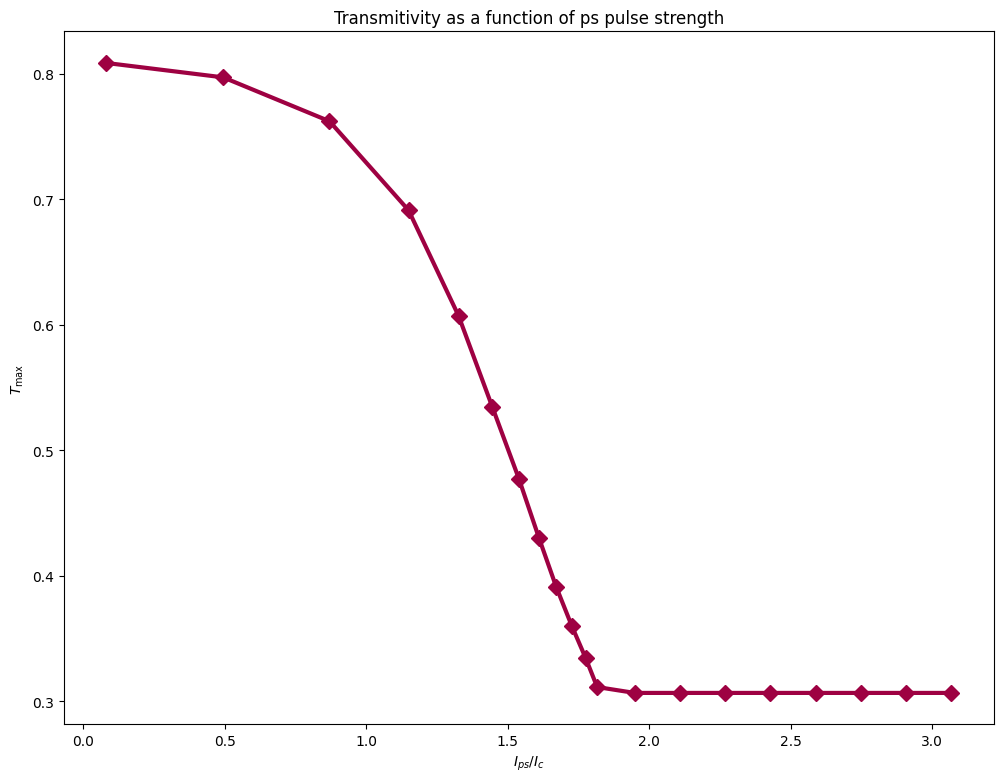

In [6]:
import matplotlib.cm as cm
import numpy as np


max_iters = [1]
scaling_factor =1 
def get_colors(N, cmap_name):
    cmap = cm.get_cmap(cmap_name)
    colors = [cmap(i) for i in np.linspace(0, 1, N)]
    return colors

# labmda = 350 nm
#filename_list = ['Transmission-for-tau_gl=7.0ps-w_vs_lambda=12.5-with_DC_bias=0.0','Transmission-for-tau_gl=5.0ps-w_vs_lambda=12.5-with_DC_bias=0.0','Transmission-for-tau_gl=3.0ps-w_vs_lambda=22.22-with_DC_bias=0.0']
#filename_list = ['Transmission-for-tau_gl=3.0ps-w_vs_lambda=1.02-with_DC_bias=0.0 and resistivity-5.31','Transmission-for-tau_gl=1.0ps-w_vs_lambda=1.02-with_DC_bias=0.0 and resistivity-5.31','Transmission-for-tau_gl=1.0ps-w_vs_lambda=0.69-with_DC_bias=0.0 and resistivity-5.31','Transmission-for-tau_gl=3.0ps-w_vs_lambda=0.69-with_DC_bias=0.0 and resistivity-5.31','Transmission-for-tau_gl=3.0ps-w_vs_lambda=0.69-with_DC_bias=0.0 and resistivity-13.27','Transmission-for-tau_gl=1.0ps-w_vs_lambda=0.69-with_DC_bias=0.0 and resistivity-13.27','Transmission-for-tau_gl=0.5ps-w_vs_lambda=0.69-with_DC_bias=0.0 and resistivity-13.27','Transmission-for-tau_gl=5.0ps-w_vs_lambda=0.69-with_DC_bias=0.0 and resistivity-13.27']
#filename_list += ['Transmission-for-tau_gl=3.0ps-w_vs_lambda=4.08-with_DC_bias=0.0 and resistivity-13.27','Transmission-for-tau_gl=3.0ps-w_vs_lambda=4.08-with_DC_bias=0.0 and resistivity-13.27']
fig, axs = plt.subplots(1,1,figsize = (12,9))
axs.set_ylabel(r'$T_{\rm max}  $')
axs.set_xlabel(r'$I_{ps}/I_c$')
axs.set_title(r'Transmitivity as a function of ps pulse strength')



#gl_times = [0.3] # 1.0
#ab_penetrations = [300]
#I_cs = [0.885]
#normal_resistances = [140]

#gl_times = [0.3,0.5]
#ab_penetrations = [300]
#I_cs = [0.885]
#normal_resistances = [150]
#sf_fractions = [2]

"""
gl_times = [2.0,1.0,0.5] # 
ab_penetrations = [300]
I_cs = [0.885]
normal_resistances = [140]
normal_fluid_collision_times = [0.8,0.01,0.3,3.0] 
sf_to_normal_fractions = [4.0,0.0]
max_iters = [1]
#normal_fluid_collision_times = [1.0,0.01]

"""

"""
gl_times = [0.3,0.5] # 0.1,0.2
ab_penetrations = [300]
I_cs = [0.885]
normal_resistances = [140]
normal_fluid_collision_times = [0.8,0.3]
sf_to_normal_fractions = [4.0,0.0]
"""

"""
gl_times = [1.0] # ,1.0,2.0,0.2
ab_penetrations = [200] # 300, 400, 200
I_cs = [2.01] # 0.885, 0.515, 2.01
normal_resistances = [140]
normal_fluid_collision_times = [0.3] # 0.3 
sf_to_normal_fractions = [0.0,4.0]
max_iter = 1
#gl_times = [1,2,3,10,15]
"""

gl_times = [0.1]
ab_penetrations = [810]
I_cs = [0.321]
normal_resistances = [220]

sf_to_normal_fractions = [0.0]
max_iter = 1

normal_fluid_collision_times = [0]
my_colors = ['teal','orange','purple','lightblue']
colors = get_colors(8, 'Spectral')
my_colors = colors

filename_list = []
for penetration_index in range(len(ab_penetrations)):
    for gl_time in gl_times:
        for normal_fluid_collision_time in normal_fluid_collision_times:
            for superfluid_fraction in sf_to_normal_fractions:
                for max_iter in max_iters:
                    ps = 1 
                    um = 1 
                    nm = 1e-3 * um
                    ohm = 1

                    t_pulse = 1 * ps #ps 

                    sample_length = 30 * um
                    light_velocity = 3e2 * um/ps
                    z_0 = 376.7 * ohm

                    width = 10 * um
                    ab_penetration = 350 * nm # 350 * nm
                    thickness = 50 * nm
                    transmission_impedance = 50 * ohm

                    auxiliary_series_impedance = 5 * ohm * 0
                    # currents are measured in units of \phi_0/2/\pi/\xi
                    # units of current I_0

                    coherence_length = 4 * nm
                    i_0 = 0.261 /coherence_length # turns current into units of mA
                    v_0 = 0.329 / coherence_length * sample_length / t_pulse # turns voltage into units of mV

                    ab_penetration = ab_penetrations[penetration_index] * nm
                    I_c = I_cs[penetration_index]
                    I_dc = 0 # run also for - this and for 14.3/18.2 biases with plus and minus
                    I_ps_list = np.linspace(0.1,15,30) * I_c 

                    N_sites = 100
                    times = np.linspace(-5,10,200)
                    resistance = normal_resistances[0]/z_0
                    parameters = {'t_p/tau_GL':t_pulse/gl_time,'tau_N/t_p': normal_fluid_collision_time/t_pulse,'resistivity':resistance * light_velocity * t_pulse/sample_length, 'W/lambda':width * thickness/ab_penetration**2, 'xi/W': coherence_length/width, 'v_0/i_0/z_T':v_0/i_0/transmission_impedance, 'v_0/i_0/z_0' : v_0/i_0/z_0, 'z_s/z_T': auxiliary_series_impedance/transmission_impedance,'sf_to_normal_fraction' : superfluid_fraction }

                    filename_list += ['YBCO-Transmission-with-resistor-for-tau_gl={}ps-w_vs_lambda={}-with_DC_bias={} and resistivity-{}'.format(np.round(1/parameters['t_p/tau_GL'],2), np.round(parameters['W/lambda'],2),np.round(I_dc/I_c,2), np.round(parameters['resistivity'],2))]


for filename in filename_list:
    params, I_ps_list,i_max_list = load_data(filename)
    I_c = params['I_c']
    #axs.scatter((i_max_list/I_c ), (i_max_list/I_ps_list  ) * scaling_factor ,linewidth = 2, label = r'$\tau_{GL} = $' + str(np.round(1/params['t_p/tau_GL'],1)) + 'ps' + ', w/lambda = ' + str(np.round(params['W/lambda'],2)) + 'R = ' + str(np.round(params['sf_to_normal_fraction'],2)) + 'L_n = ' + str(np.round(params['tau_N/t_p'],2)), color = my_colors[filename_list.index(filename) % len(my_colors)],edgecolor = 'black', zorder = 10, s = 130)
    x_data = i_max_list/I_c
    y_data = (i_max_list/I_ps_list  ) * scaling_factor
    axs.plot(x_data, y_data,linewidth = 3, label = r'$\tau_{GL} = $' + str(np.round(1/params['t_p/tau_GL'],1)) + 'ps' + r', $\lambda^2/wd$ = ' + str(np.round(1/params['W/lambda'],2)), color = my_colors[filename_list.index(filename) % len(my_colors)], zorder = 10, marker = 'D', markersize = 8)
    save_two_column_text(data = np.array([x_data,y_data]).T,filename='YBCO_GL' + filename + '.dat')

I_c = 11
axs.scatter(np.abs(sc_data_x)/I_c , sc_data_y, color = 'dodgerblue', marker = 'o',label = r'$T = 7K$', edgecolors='black', s = 50, linewidth = 1.5)
axs.scatter(np.abs(normal_data_x)/I_c , normal_data_y, color = 'thistle', marker = 'o',label =  r'$T = 20K$', edgecolors='firebrick', s = 50, linewidth = 2)

plt.legend()

plt.show()

